Netflix Data Analysis Project

# Introduction

This project focuses on analyzing Netflix movies and TV shows dataset. The main objective is to explore the data and understand patterns related to content type, release year, country, and ratings.

The analysis helps in identifying trends such as the distribution of movies and TV shows, growth of content over the years, and the most common categories available on Netflix.

This project is performed using Python with libraries like NumPy, Pandas, Matplotlib, and Seaborn for data analysis and visualization.


# Dataset Understanding

The dataset contains information about Netflix movies and TV shows. It includes details such as title, type, country, release year, rating, and duration.

By looking at the initial rows of the dataset, we can understand the structure and the type of data present in each column.

In [1]:
import os
os.listdir()

['.ipynb_checkpoints', 'netflix_analysis.ipynb', 'netflix_titles.csv']

In [4]:
import pandas as pd
df=pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


The dataset contains multiple columns such as title, type, country, release year, rating, and duration.
Each column represents specific information about Netflix content. By examining the dataset structure, we can understand the type of data present and identify any missing values.

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
# Data cleaning
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

The dataset contains missing values in several columns such as director, cast, and country.
Columns like rating, duration, and date_added have very few missing values, which can be handled easily.
Some columns with large number of missing values may be ignored or handled carefully during analysis.

In [11]:
df.dropna(subset=['rating','duration','date_added'],inplace=True)
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


Questions for Analysis
1. What is the distribution of Movies and TV Shows on Netflix?
2. Which countries produce the highest number of Netflix content?
3. How has the number of releases changed over the years?
4. What are the most common content ratings on Netflix?
5. Which genres are most frequently available on Netflix?

In [12]:
count=df['type'].value_counts()
count

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [15]:
df['country'].value_counts()

country
United States                                    2809
India                                             972
United Kingdom                                    418
Japan                                             243
South Korea                                       199
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 748, dtype: int64

In [31]:
released_yr = df['release_year'].value_counts().sort_index()
print(released_yr)

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


In [19]:
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [21]:
df['listed_in'].value_counts()

listed_in
Dramas, International Movies                                  362
Documentaries                                                 359
Stand-Up Comedy                                               334
Comedies, Dramas, International Movies                        274
Dramas, Independent Movies, International Movies              252
                                                             ... 
Dramas, Horror Movies, Sci-Fi & Fantasy                         1
British TV Shows, TV Dramas, TV Sci-Fi & Fantasy                1
Comedies, Cult Movies, Sports Movies                            1
Action & Adventure, Faith & Spirituality, Sci-Fi & Fantasy      1
Cult Movies, Dramas, Thrillers                                  1
Name: count, Length: 513, dtype: int64

In [24]:
import matplotlib.pyplot as plt

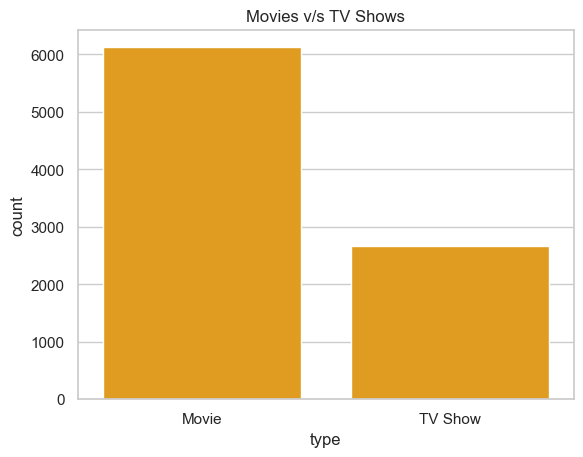

In [36]:
import seaborn as sns
sns.set(style="whitegrid")
sns.countplot(x='type', data=df,color='orangeb')
plt.title("Movies v/s TV Shows")
plt.show()

Movies are more in number compared to TV Shows on Netflix. 
This indicates that Netflix focuses more on movie content.

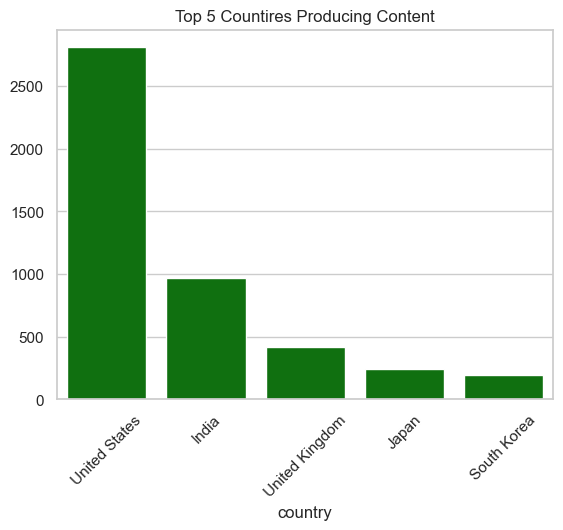

In [42]:
top_countries=df['country'].value_counts().head(5)
sns.barplot(x=top_countries.index,y=top_countries.values,color='green')
plt.title("Top 5 Countires Producing Content")
plt.xticks(rotation=45)
plt.show()

The United States produces the highest amount of Netflix content, followed by other countries. This shows that Netflix content is dominated by a few major countries.

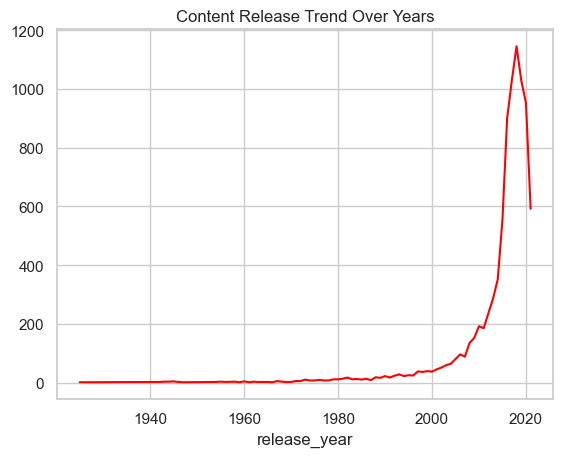

In [33]:
sns.lineplot(x=released_yr.index,y=released_yr.values,color='red')
plt.title("Content Release Trend Over Years")
plt.show()

The number of releases has increased significantly over the yearsshowing the rapid growth of Netflix content in recent times.

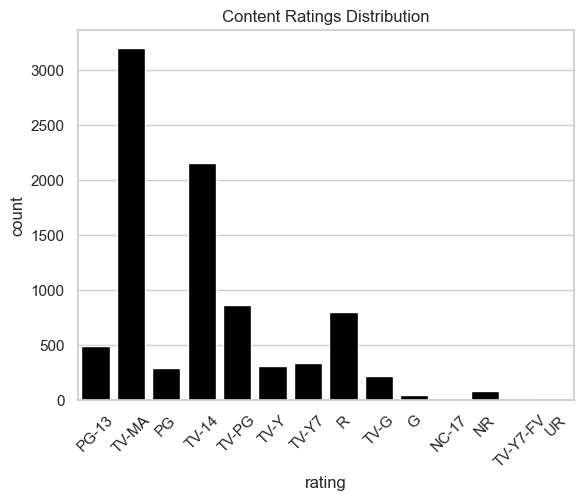

In [39]:
sns.countplot(x='rating', data=df,color='black')
plt.title("Content Ratings Distribution")
plt.xticks(rotation=45)
plt.show()

Most of the content falls under specific ratings such as TV-MA and TV-14indicating that Netflix targets a wide range of audiences including adults and teenagers.

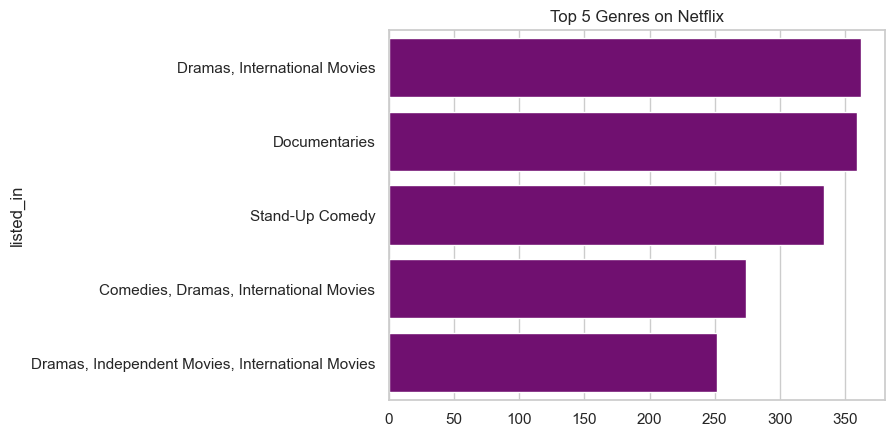

In [41]:
top_genres = df['listed_in'].value_counts().head(5)
sns.barplot(x=top_genres.values, y=top_genres.index,color='purple')
plt.title("Top 5 Genres on Netflix")
plt.show()

Certain genres like Drama and Comedy are more frequently available on Netflix, showing audience preference for these categories.

# Conclusion:
From the analysis of the Netflix dataset, it is observed that movies are more prevalent than TV shows on the platform. The majority of content is produced by countries like the United States, indicating its dominance in content creation.

Over the years, Netflix has shown significant growth in content production. The distribution of ratings suggests that the platform caters to a wide audience, including both adults and younger viewers.

Additionally, popular genres such as Drama and Comedy are highly available, reflecting user preferences. Overall, the analysis highlights key trends and patterns in Netflix content.
